In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import cm
import math
import seaborn as sns
import pickle
import copy

import torch
from torch import nn, Tensor

import time
import joblib

from flow_matching.path.scheduler import CondOTScheduler
from flow_matching.path import AffineProbPath
from flow_matching.solver import Solver, ODESolver
from flow_matching.utils import ModelWrapper

from sklearn.model_selection import train_test_split

import warnings

warnings.filterwarnings("ignore", category=UserWarning, module='torch')

from xgboost import XGBClassifier


In [13]:
import sys
import os

sys.path.append(os.path.abspath(".."))

from fm.seed import set_seed
import fm.data as data
import fm.model as model
import fm.training as training
import fm.physics as physics
import fm.massesPlots as massesPlots
import fm.lossPlots as lossPlots
import fm.analysis as analysis
import fm.BDT_FeaturesEngineering as addFeatures

In [14]:
# for the plots :
import mplhep as hep

plt.style.use(hep.style.CMS)

plt.rcParams.update({
    "axes.titlesize": 12,
    "axes.labelsize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
    "figure.titlesize": 13,

    "lines.linewidth": 2,

    "axes.grid": True,
    "grid.alpha": 0.25,
    "grid.linestyle": "-",

    "legend.frameon": False,
})


In [15]:
with open("df_H_event+btag.pkl", "rb") as f:
    df_H_event = pickle.load(f)

with open("df_DY_event+btag.pkl", "rb") as f:
    df_DY_event = pickle.load(f)

with open("df_TT_event+btag.pkl", "rb") as f:
    df_TT_event = pickle.load(f)

In [16]:
# carico train set e test set del FM:
#   - il train set verrà bilanciato e splittato in train e test per il BDT
#   - il test set verrà usato come test indipendente del BDT + FM

base = "../results/prepared_splits_DY_H_TT_btag"

df_train_FM = pd.read_pickle(
    f"{base}/unbalanced/X_NONE__Y_NONE/train.pkl"
)

df_test_FM = pd.read_pickle(
    f"{base}/unbalanced/X_NONE__Y_NONE/test.pkl"
)

## Features

In [22]:
df_train_FM_allFeatures = addFeatures.add_derived_bdt_features(df_train_FM)

N_bal = df_train_FM_allFeatures["class"].value_counts().min()

df_BDT = (
    df_train_FM_allFeatures
    .groupby("class", group_keys=False)
    .sample(n=N_bal, random_state=0)
    .sample(frac=1.0, random_state=0)
    .reset_index(drop=True)
)

In [24]:
exclude_cols = [
    "class",
    "tau1_corr",
    "tau2_corr",
    "tau1_gen_pt",
    "tau2_gen_pt",
    "tau1_gen_eta",
    "tau2_gen_eta",
    "tau1_gen_phi",
    "tau2_gen_phi",
    "tau1_gen_mass",
    "tau2_gen_mass",
    "m_gen",
]

bdt_cols = [
    c for c in df_train_FM_allFeatures.columns
    if c not in exclude_cols
]

In [25]:
print("N features:", len(bdt_cols))
print(bdt_cols)

N features: 138
['tau1_pt', 'tau1_eta', 'tau1_phi', 'tau1_mass', 'tau1_dxy', 'tau1_dz', 'tau1_ptCorrPNet', 'tau1_rawPNetVSjet', 'tau1_rawDeepTau2018v2p5VSjet', 'tau1_charge', 'tau1_dM_0', 'tau1_dM_1', 'tau1_dM_2', 'tau1_dM_10', 'tau1_dM_11', 'tau1_leadTkDeltaEta', 'tau1_leadTkDeltaPhi', 'tau1_leadTkPtOverTauPt', 'tau2_pt', 'tau2_eta', 'tau2_phi', 'tau2_mass', 'tau2_dxy', 'tau2_dz', 'tau2_ptCorrPNet', 'tau2_rawPNetVSjet', 'tau2_rawDeepTau2018v2p5VSjet', 'tau2_charge', 'tau2_dM_0', 'tau2_dM_1', 'tau2_dM_2', 'tau2_dM_10', 'tau2_dM_11', 'tau2_leadTkDeltaEta', 'tau2_leadTkDeltaPhi', 'tau2_leadTkPtOverTauPt', 'MET_pt', 'MET_phi', 'MET_covXX', 'MET_covXY', 'MET_covYY', 'MET_significance', 'MET_sumEt', 'MET_sumPtUnclustered', 'jet1_pt', 'jet1_eta', 'jet1_phi', 'jet1_mass', 'jet1_btagDeepFlavB', 'jet1_btagDeepFlavCvB', 'jet1_btagDeepFlavCvL', 'jet1_btagDeepFlavQG', 'jet1_btagPNetB', 'jet1_btagPNetCvB', 'jet1_btagPNetCvL', 'jet1_btagPNetQvG', 'jet1_btagPNetTauVJet', 'jet1_btagRobustParTAK4B', 'j

In [26]:
bad_cols = [
    "process",
    "label",

    "tau1_gen_logpt",
    "tau2_gen_logpt",

    "m_vis_ptcorr",
    "m_fastmtt",
]

In [27]:
bdt_cols = [c for c in bdt_cols if c not in bad_cols]

print("N features:", len(bdt_cols))
print(bdt_cols)

N features: 132
['tau1_pt', 'tau1_eta', 'tau1_phi', 'tau1_mass', 'tau1_dxy', 'tau1_dz', 'tau1_ptCorrPNet', 'tau1_rawPNetVSjet', 'tau1_rawDeepTau2018v2p5VSjet', 'tau1_charge', 'tau1_dM_0', 'tau1_dM_1', 'tau1_dM_2', 'tau1_dM_10', 'tau1_dM_11', 'tau1_leadTkDeltaEta', 'tau1_leadTkDeltaPhi', 'tau1_leadTkPtOverTauPt', 'tau2_pt', 'tau2_eta', 'tau2_phi', 'tau2_mass', 'tau2_dxy', 'tau2_dz', 'tau2_ptCorrPNet', 'tau2_rawPNetVSjet', 'tau2_rawDeepTau2018v2p5VSjet', 'tau2_charge', 'tau2_dM_0', 'tau2_dM_1', 'tau2_dM_2', 'tau2_dM_10', 'tau2_dM_11', 'tau2_leadTkDeltaEta', 'tau2_leadTkDeltaPhi', 'tau2_leadTkPtOverTauPt', 'MET_pt', 'MET_phi', 'MET_covXX', 'MET_covXY', 'MET_covYY', 'MET_significance', 'MET_sumEt', 'MET_sumPtUnclustered', 'jet1_pt', 'jet1_eta', 'jet1_phi', 'jet1_mass', 'jet1_btagDeepFlavB', 'jet1_btagDeepFlavCvB', 'jet1_btagDeepFlavCvL', 'jet1_btagDeepFlavQG', 'jet1_btagPNetB', 'jet1_btagPNetCvB', 'jet1_btagPNetCvL', 'jet1_btagPNetQvG', 'jet1_btagPNetTauVJet', 'jet1_btagRobustParTAK4B', 'j

In [28]:
bad_cols += [
    "tau1_pt",
    "tau2_pt",

    "tau1_pt_reco",
    "tau2_pt_reco",

    "tau1_pt_reco_corrPNet",
    "tau2_pt_reco_corrPNet",

    "tau1_pt_for_features",
    "tau2_pt_for_features",
]

bdt_cols = [c for c in bdt_cols if c not in bad_cols]

print("N features:", len(bdt_cols))

N features: 124


In [31]:
# check:
print(df_BDT["class"].value_counts())

class
2    15070
0    15070
1    15070
Name: count, dtype: int64


---
# BDT

In [32]:
from sklearn.model_selection import train_test_split

X = df_BDT[bdt_cols]
y = df_BDT["class"].astype(int)

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=0,
    stratify=y,
)

print("BDT train:", X_train.shape)
print("BDT val  :", X_val.shape)

print(y_train.value_counts())
print(y_val.value_counts())

BDT train: (36168, 124)
BDT val  : (9042, 124)
class
2    12056
0    12056
1    12056
Name: count, dtype: int64
class
2    3014
1    3014
0    3014
Name: count, dtype: int64


## Training

In [35]:
bdt = XGBClassifier(
    objective="multi:softprob",
    num_class=3,
    eval_metric=["mlogloss", "merror"],

    n_estimators=2000,
    max_depth=4,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=1.0,
    min_child_weight=1,

    random_state=0,
    n_jobs=-1,
    early_stopping_rounds=100,
)

In [36]:
bdt.fit(
    X_train,
    y_train,
    eval_set=[
        (X_train, y_train),
        (X_val, y_val),
    ],
    verbose=True,
)

[0]	validation_0-mlogloss:1.00687	validation_0-merror:0.16407	validation_1-mlogloss:1.00754	validation_1-merror:0.17264
[1]	validation_0-mlogloss:0.93004	validation_0-merror:0.16260	validation_1-mlogloss:0.93118	validation_1-merror:0.16998
[2]	validation_0-mlogloss:0.86481	validation_0-merror:0.15843	validation_1-mlogloss:0.86615	validation_1-merror:0.16357
[3]	validation_0-mlogloss:0.80825	validation_0-merror:0.16249	validation_1-mlogloss:0.81001	validation_1-merror:0.16833
[4]	validation_0-mlogloss:0.75949	validation_0-merror:0.16354	validation_1-mlogloss:0.76146	validation_1-merror:0.16987
[5]	validation_0-mlogloss:0.71693	validation_0-merror:0.16360	validation_1-mlogloss:0.71917	validation_1-merror:0.16932
[6]	validation_0-mlogloss:0.67941	validation_0-merror:0.15989	validation_1-mlogloss:0.68160	validation_1-merror:0.16656
[7]	validation_0-mlogloss:0.64573	validation_0-merror:0.15984	validation_1-mlogloss:0.64790	validation_1-merror:0.16479
[8]	validation_0-mlogloss:0.61608	valida

,objective,'multi:softprob'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,1.0
,device,None
,early_stopping_rounds,100
,enable_categorical,False
,eval_metric,"['mlogloss', 'merror']"


In [37]:
print("Best iteration:", bdt.best_iteration)
print("Best score:", bdt.best_score)

Best iteration: 325
Best score: 0.12242866622428666


In [38]:
# predizioni:
y_val_pred = bdt.predict(X_val)

In [39]:
# report:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_val,
        y_val_pred,
        target_names=["DY", "H", "TTbar"]
    )
)

              precision    recall  f1-score   support

          DY       0.80      0.84      0.82      3014
           H       0.83      0.80      0.81      3014
       TTbar       1.00      0.99      1.00      3014

    accuracy                           0.88      9042
   macro avg       0.88      0.88      0.88      9042
weighted avg       0.88      0.88      0.88      9042



In [40]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_val, y_val_pred)

print(cm)

[[2537  473    4]
 [ 608 2404    2]
 [   9   11 2994]]


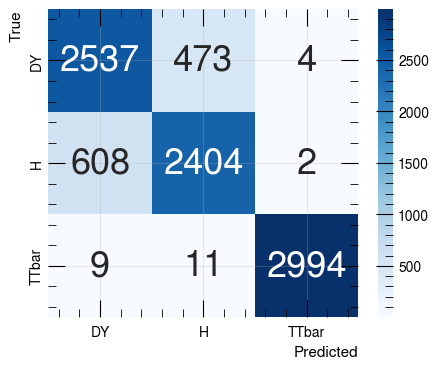

In [41]:
import seaborn as sns

cm = confusion_matrix(y_val, y_val_pred)

plt.figure(figsize=(5,4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["DY", "H", "TTbar"],
    yticklabels=["DY", "H", "TTbar"],
)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

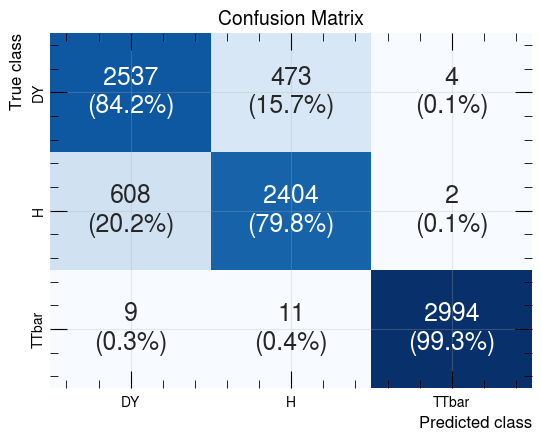

In [94]:
cm = confusion_matrix(y_val, y_val_pred)

cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

labels = np.array([
    [
        f"{cm[i,j]}\n({100*cm_norm[i,j]:.1f}%)"
        for j in range(cm.shape[1])
    ]
    for i in range(cm.shape[0])
])

plt.figure(figsize=(6,5))

sns.heatmap(
    cm_norm * 100,
    annot=labels,
    fmt="",
    cmap="Blues",
    cbar=False,                    
    xticklabels=["DY", "H", "TTbar"],
    yticklabels=["DY", "H", "TTbar"],
    annot_kws={"fontsize":18}     
)

plt.xlabel("Predicted class", fontsize=12)
plt.ylabel("True class", fontsize=12)
plt.title("Confusion Matrix", fontsize=14)

plt.tight_layout()
plt.show()

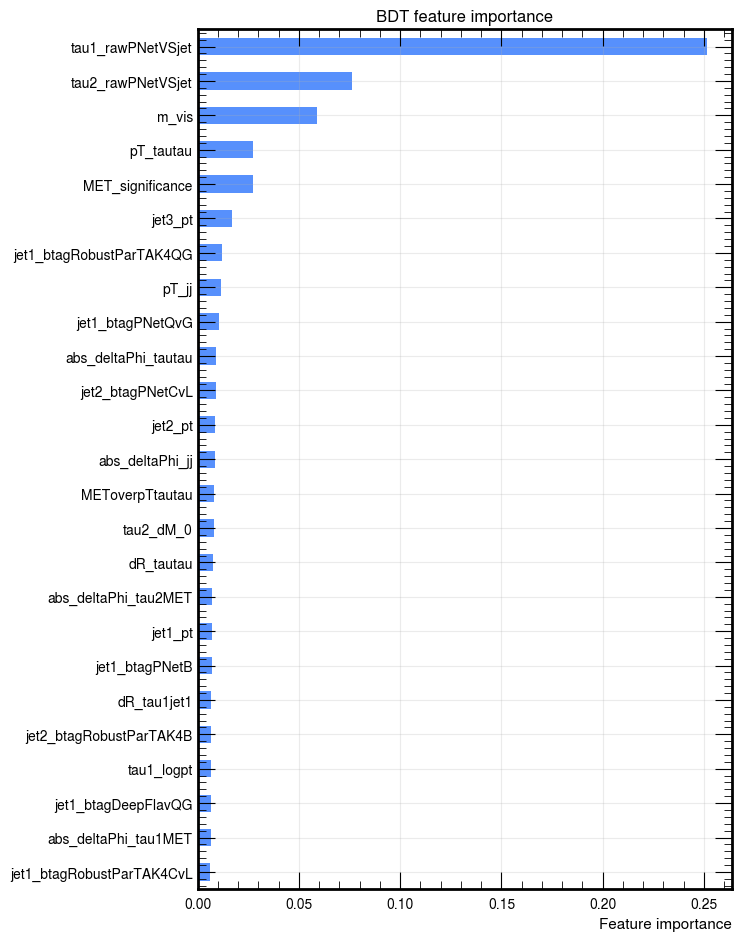

In [43]:
importance = pd.Series(
    bdt.feature_importances_,
    index=bdt_cols
).sort_values(ascending=False)

plt.figure(figsize=(8,10))

importance.head(25).sort_values().plot(
    kind="barh"
)

plt.xlabel("Feature importance")
plt.ylabel("")
plt.title("BDT feature importance")

plt.tight_layout()
plt.show()

# FM

In [44]:
# carico il test set del FM:
df_test_FM = pd.read_pickle(
    "../results/prepared_splits_DY_H_TT_btag/unbalanced/X_NONE__Y_NONE/test.pkl"
)

# e aggiungo le features del BDT:
df_test_FM_feat = addFeatures.add_derived_bdt_features(
    df_test_FM.copy()
)

In [45]:
X_test_BDT = df_test_FM_feat[bdt_cols]

In [56]:
# classe predetta:
pred_class = bdt.predict(X_test_BDT)

# probabilità delle tre classi:
proba = bdt.predict_proba(X_test_BDT)

In [57]:
print("True classes")
print(df_test_FM_feat["class"].value_counts())

print("\nPredicted classes")
print(df_test_FM_feat["pred_class"].value_counts())

True classes
class
2    13814
1     6948
0     1907
Name: count, dtype: int64

Predicted classes
pred_class
2    13739
1     5911
0     3019
Name: count, dtype: int64


In [51]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    df_test_FM_feat["class"],
    df_test_FM_feat["pred_class"]
)

print(cm)

[[ 1581   323     3]
 [ 1390  5554     4]
 [   48    34 13732]]


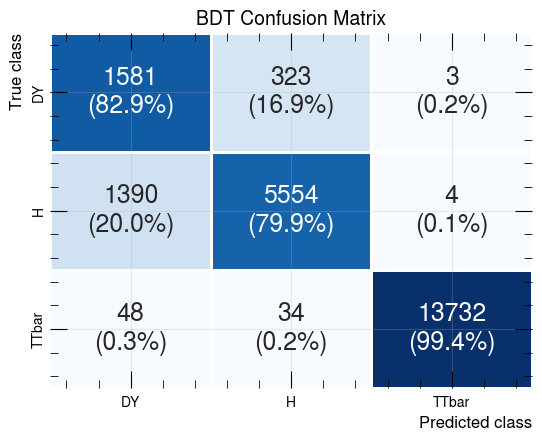

In [96]:
cm = np.array([
    [1581,  323,     3],
    [1390, 5554,     4],
    [  48,   34, 13732]
])

cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

labels = np.array([
    [
        f"{cm[i,j]}\n({100*cm_norm[i,j]:.1f}%)"
        for j in range(cm.shape[1])
    ]
    for i in range(cm.shape[0])
])

plt.figure(figsize=(6,5))

sns.heatmap(
    cm_norm * 100,
    annot=labels,
    fmt="",
    cmap="Blues",
    cbar=False,
    xticklabels=["DY", "H", "TTbar"],
    yticklabels=["DY", "H", "TTbar"],
    annot_kws={"fontsize":18},
    linewidths=1,
    linecolor="white"
)

plt.xlabel("Predicted class", fontsize=12)
plt.ylabel("True class", fontsize=12)
plt.title("BDT Confusion Matrix", fontsize=14)
plt.tight_layout()
plt.show()

In [58]:
# Salvo i risultati del BDT dentro il dataframe:

df_test_FM_feat["pred_class"] = pred_class

df_test_FM_feat["p_DY"] = proba[:,0]
df_test_FM_feat["p_H"] = proba[:,1]
df_test_FM_feat["p_TT"] = proba[:,2]

In [59]:
# carico le run unbalanced del FM:
OUT_ROOT = "../results/runs_DY_H_TT_btag"

tag = "HUBER_pat100_ep5000_seed0_hidden256x5_btag_TTbar_multiclassScaling"

MODES = [
    "X_LOCAL__Y_LOCAL",
]

RESULTS = {"unbalanced": {}}

for mode in MODES:

    run_dir = os.path.join(
        OUT_ROOT,
        "unbalanced",
        tag,
        mode,
    )

    RESULTS["unbalanced"][mode] = training.load_run(run_dir)

    print("loaded ->", run_dir)

loaded -> ../results/runs_DY_H_TT_btag/unbalanced/HUBER_pat100_ep5000_seed0_hidden256x5_btag_TTbar_multiclassScaling/X_LOCAL__Y_LOCAL


In [60]:
# Faccio inferenza FM local usando pred_class:

# preparo dataframe per BDT-guided LOCAL scaling
df_test_BDTguided = df_test_FM.copy().reset_index(drop=True)

# salvo la classe vera per l'analisi finale
df_test_BDTguided["true_class"] = df_test_BDTguided["class"].values

# sostituisco class con la classe predetta dal BDT
# questa è la colonna che il LOCAL scaling userà per scegliere lo scaler
df_test_BDTguided["class"] = df_test_FM_feat["pred_class"].values

In [61]:
res_local = RESULTS["unbalanced"]["X_LOCAL__Y_LOCAL"]

pred_bdt_guided = model.predict_tau_corr_auto_multiclass(
    df=df_test_BDTguided,
    res=res_local,
    train_cols=res_local["train_cols"],
    y_cols=res_local["y_cols"],
)

In [62]:
pred_bdt_guided = pred_bdt_guided.reset_index(drop=True)

pred_bdt_guided["class"] = df_test_BDTguided["true_class"].values
pred_bdt_guided["pred_class"] = df_test_BDTguided["class"].values

In [64]:
pred_bdt_guided.head(10)

,tau1_corr_pred,tau2_corr_pred,class,pred_class
0,0.929999,0.925071,2,2
1,1.550431,2.241496,1,1
2,0.824644,0.916938,2,2
3,1.100911,1.051473,1,1
4,1.238342,1.126066,1,0
5,1.163316,1.022799,2,2
6,1.101882,0.910785,2,2
7,1.084404,1.130537,1,1
8,0.953308,1.657262,0,0
9,1.260203,1.499874,0,0


## m$_{\tau\tau}$

In [66]:
def compute_mtautau_from_pt(df, pt1_col, pt2_col):
    pt1 = df[pt1_col].to_numpy()
    eta1 = df["tau1_eta"].to_numpy()
    phi1 = df["tau1_phi"].to_numpy()
    m1   = df["tau1_mass"].to_numpy()

    pt2 = df[pt2_col].to_numpy()
    eta2 = df["tau2_eta"].to_numpy()
    phi2 = df["tau2_phi"].to_numpy()
    m2   = df["tau2_mass"].to_numpy()

    px1 = pt1 * np.cos(phi1)
    py1 = pt1 * np.sin(phi1)
    pz1 = pt1 * np.sinh(eta1)
    E1  = np.sqrt(px1**2 + py1**2 + pz1**2 + m1**2)

    px2 = pt2 * np.cos(phi2)
    py2 = pt2 * np.sin(phi2)
    pz2 = pt2 * np.sinh(eta2)
    E2  = np.sqrt(px2**2 + py2**2 + pz2**2 + m2**2)

    E  = E1 + E2
    px = px1 + px2
    py = py1 + py2
    pz = pz1 + pz2

    m2_tot = E**2 - px**2 - py**2 - pz**2
    return np.sqrt(np.clip(m2_tot, 0, None))

In [67]:
df_bdt_guided_mtautau = df_test_FM.copy().reset_index(drop=True)

df_bdt_guided_mtautau["tau1_pt_FM"] = (
    df_bdt_guided_mtautau["tau1_pt_reco_corrPNet"]
    * pred_bdt_guided["tau1_corr_pred"].values
)

df_bdt_guided_mtautau["tau2_pt_FM"] = (
    df_bdt_guided_mtautau["tau2_pt_reco_corrPNet"]
    * pred_bdt_guided["tau2_corr_pred"].values
)

df_bdt_guided_mtautau["mtautau_BDTguided"] = compute_mtautau_from_pt(
    df_bdt_guided_mtautau,
    pt1_col="tau1_pt_FM",
    pt2_col="tau2_pt_FM",
)

# salvo anche info utili
df_bdt_guided_mtautau["pred_class"] = pred_bdt_guided["pred_class"].values
df_bdt_guided_mtautau["true_class"] = pred_bdt_guided["class"].values

df_bdt_guided_mtautau[[
    "class",
    "true_class",
    "pred_class",
    "mtautau_BDTguided"
]].head()

,class,true_class,pred_class,mtautau_BDTguided
0,2,2,2,149.850320
1,1,1,1,119.474308
2,2,2,2,71.321252
3,1,1,1,128.149823
4,1,1,0,101.698495


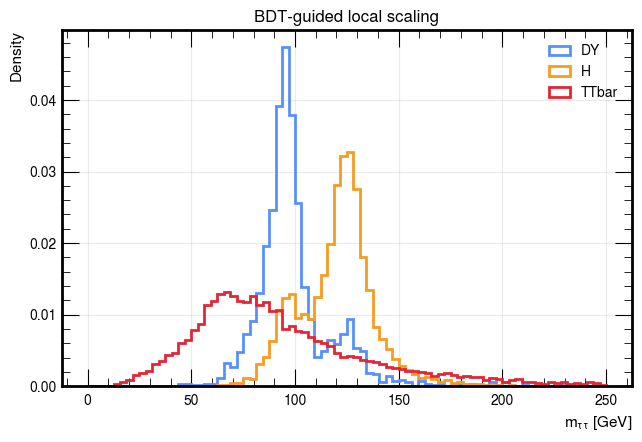

In [75]:
class_map = {
    0: "DY",
    1: "H",
    2: "TTbar",
}

plt.figure(figsize=(7, 5))

for cls, name in class_map.items():

    tmp = df_bdt_guided_mtautau[
        df_bdt_guided_mtautau["class"] == cls
    ]

    plt.hist(
        tmp["mtautau_BDTguided"],
        bins=80,
        range=(0, 250),
        density=True,
        histtype="step",
        linewidth=2.0,
        label=name,
    )

plt.xlabel(r"$m_{\tau\tau}$ [GeV]")
plt.ylabel("Density")
plt.title("BDT-guided local scaling")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

In [70]:
import joblib

mtautau_results = joblib.load(
    "../results/mtautau_results_DY_H_TT_btag.joblib"
)

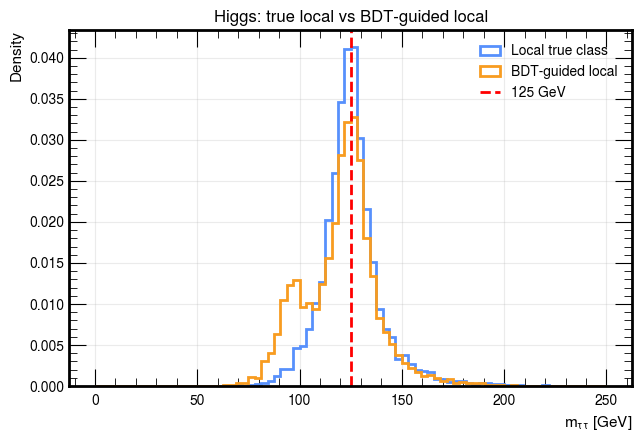

In [72]:
plt.figure(figsize=(7, 5))

h_local = mtautau_results["unbalanced"]["X_LOCAL__Y_LOCAL"]
h_local = h_local[h_local["class"] == 1]

h_bdt = df_bdt_guided_mtautau[
    df_bdt_guided_mtautau["class"] == 1
]

plt.hist(
    h_local["mtautau_FM"],
    bins=80,
    range=(0, 250),
    density=True,
    histtype="step",
    linewidth=2,
    label="Local true class",
)

plt.hist(
    h_bdt["mtautau_BDTguided"],
    bins=80,
    range=(0, 250),
    density=True,
    histtype="step",
    linewidth=2,
    label="BDT-guided local",
)

plt.axvline(125, linestyle="--", label="125 GeV", color = 'red')

plt.xlabel(r"$m_{\tau\tau}$ [GeV]")
plt.ylabel("Density")
plt.title("Higgs: true local vs BDT-guided local")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

In [74]:
for name, masses in [
    ("LOCAL", h_local["mtautau_FM"]),
    ("BDT_GUIDED", h_bdt["mtautau_BDTguided"]),
]:
    print("\n", name)
    print("mean   =", masses.mean())
    print("median =", masses.median())
    print("std    =", masses.std())
    print("q16    =", masses.quantile(0.16))
    print("q84    =", masses.quantile(0.84))


 LOCAL
mean   = 125.25516294502984
median = 124.42594841242371
std    = 15.168040487318967
q16    = 113.34312753698411
q84    = 135.76144520579217

 BDT_GUIDED
mean   = 120.22179256920492
median = 122.16394008896151
std    = 18.50295290319303
q16    = 99.62605265327498
q84    = 134.4504631169403


## Analysis

In [82]:
import joblib

mtautau_results = joblib.load(
    "../results/mtautau_results_DY_H_TT_btag.joblib"
)

In [83]:
print(mtautau_results.keys())

print(
    mtautau_results["unbalanced"].keys()
)

dict_keys(['unbalanced', 'balanced'])
dict_keys(['X_NONE__Y_NONE', 'X_GLOBAL__Y_GLOBAL', 'X_LOCAL__Y_LOCAL'])


In [86]:
rows = []

methods = {
    "NONE": mtautau_results["unbalanced"]["X_NONE__Y_NONE"].rename(
        columns={"mtautau_FM": "mass"}
    ),
    "GLOBAL": mtautau_results["unbalanced"]["X_GLOBAL__Y_GLOBAL"].rename(
        columns={"mtautau_FM": "mass"}
    ),
    "LOCAL": mtautau_results["unbalanced"]["X_LOCAL__Y_LOCAL"].rename(
        columns={"mtautau_FM": "mass"}
    ),
    "BDT_GUIDED_LOCAL": df_bdt_guided_mtautau.rename(
        columns={"mtautau_BDTguided": "mass"}
    ),
}

for method, df_tmp in methods.items():

    masses_H = df_tmp[df_tmp["class"] == 1]["mass"].to_numpy()

    mu, sigma, low, high = analysis.fit_signal_window(masses_H)

    for background, bkg_classes in {
        "DY": [0],
        "DY+TTbar": [0, 2],
    }.items():

        masses_B = df_tmp[df_tmp["class"].isin(bkg_classes)]["mass"].to_numpy()

        S, B, SB, SsqrtB = analysis.compute_SB(
            signal=masses_H,
            background=masses_B,
            window=(low, high),
        )

        rows.append({
            "method": method,
            "background": background,
            "mu_H": mu,
            "sigma_H": sigma,
            "window_low": low,
            "window_high": high,
            "S": S,
            "B": B,
            "S/B": SB,
            "S/sqrtB": SsqrtB,
        })

SB_all_df = pd.DataFrame(rows)

display(SB_all_df[SB_all_df["background"] == "DY"])
display(SB_all_df[SB_all_df["background"] == "DY+TTbar"])

,method,background,mu_H,sigma_H,window_low,window_high,S,B,S/B,S/sqrtB
0,NONE,DY,122.377398,25.289813,71.797773,172.957023,6649,1760,3.777841,158.489319
2,GLOBAL,DY,120.462724,16.825193,86.812338,154.113110,6585,1580,4.167722,165.663654
4,LOCAL,DY,125.255163,15.166949,94.921265,155.589061,6565,969,6.775026,210.898185
6,BDT_GUIDED_LOCAL,DY,120.221793,18.501621,83.218550,157.225035,6641,1648,4.029733,163.589293


,method,background,mu_H,sigma_H,window_low,window_high,S,B,S/B,S/sqrtB
1,NONE,DY+TTbar,122.377398,25.289813,71.797773,172.957023,6649,9719,0.684124,67.444345
3,GLOBAL,DY+TTbar,120.462724,16.825193,86.812338,154.113110,6585,6645,0.990971,80.780825
5,LOCAL,DY+TTbar,125.255163,15.166949,94.921265,155.589061,6565,4926,1.332724,93.537881
7,BDT_GUIDED_LOCAL,DY+TTbar,120.221793,18.501621,83.218550,157.225035,6641,7330,0.906003,77.567803


## Confidence threshold test

In [88]:
df_bdt_guided_mtautau["max_proba"] = np.max(proba, axis=1)

for threshold in [0.7, 0.8, 0.9]:

    tmp = df_bdt_guided_mtautau[
        df_bdt_guided_mtautau["max_proba"] > threshold
    ]

    print("\nthreshold =", threshold)
    print("N events =", len(tmp))
    print(tmp["class"].value_counts().sort_index())

    masses_H = tmp[tmp["class"] == 1]["mtautau_BDTguided"].to_numpy()
    masses_DY = tmp[tmp["class"] == 0]["mtautau_BDTguided"].to_numpy()
    masses_B = tmp[tmp["class"].isin([0, 2])]["mtautau_BDTguided"].to_numpy()

    mu, sigma, low, high = analysis.fit_signal_window(masses_H)

    S, B, SB, SsqrtB = analysis.compute_SB(
        signal=masses_H,
        background=masses_DY,
        window=(low, high),
    )

    print("DY only:")
    print("S/B =", SB)
    print("S/sqrtB =", SsqrtB)

    S, B, SB, SsqrtB = analysis.compute_SB(
        signal=masses_H,
        background=masses_B,
        window=(low, high),
    )

    print("DY+TTbar:")
    print("S/B =", SB)
    print("S/sqrtB =", SsqrtB)


threshold = 0.7
N events = 20488
class
0     1431
1     5299
2    13758
Name: count, dtype: int64
DY only:
S/B = 4.531588447653429
S/sqrtB = 150.84132588805983
DY+TTbar:
S/B = 0.8091861402095084
S/sqrtB = 63.741066903464535

threshold = 0.8
N events = 19167
class
0     1065
1     4368
2    13734
Name: count, dtype: int64
DY only:
S/B = 5.7073509015256585
S/sqrtB = 153.25060835043394
DY+TTbar:
S/B = 0.7502278942570647
S/sqrtB = 55.56246741162438

threshold = 0.9
N events = 17065
class
0      548
1     2836
2    13681
Name: count, dtype: int64
DY only:
S/B = 10.89795918367347
S/sqrtB = 170.58004285498396
DY+TTbar:
S/B = 0.6061293984108967
S/sqrtB = 40.22891365370303
